# EMG Gesture Classifier

### Human-Robot Interface Signal Pipeline

**Run all cells top to bottom in order. Never skip a cell.**  
To reset: Kernel → Restart & Run All Cells


In [14]:
from src.classifier import GestureClassifier
from src.feature_extractor import FeatureExtractor
from src.signal_processor import SignalProcessor
from src.data_loader import EMGDataLoader
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

sys.path.append('..')

os.makedirs('../figures', exist_ok=True)

print('All imports successful.')

All imports successful.


Loaded ../data/S1_E1_A1.mat
  Samples: 101,014  Channels: 10
  Unique labels found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
After filtering to gestures [1, 2, 3, 4, 5, 6]:
  Remaining samples: 20,567
  Gesture 1: 3,815 samples
  Gesture 2: 2,618 samples
  Gesture 3: 4,142 samples
  Gesture 4: 2,982 samples
  Gesture 5: 3,952 samples
  Gesture 6: 3,058 samples


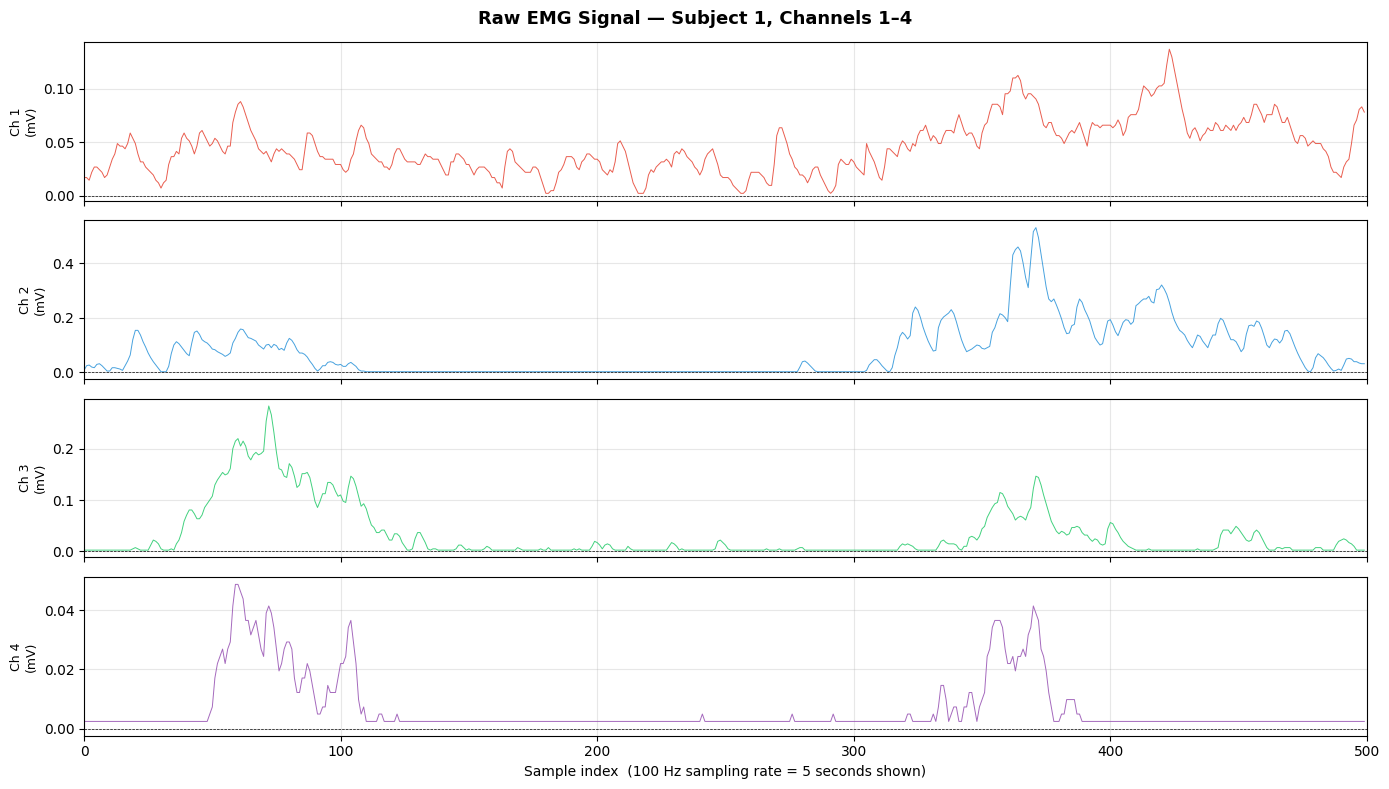

Figure saved: figures/raw_signal.png


In [15]:
loader = EMGDataLoader('../data/S1_E1_A1.mat').load().filter_gestures()

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Raw EMG Signal — Subject 1, Channels 1–4',
             fontsize=13, fontweight='bold')

colours = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
for i, ax in enumerate(axes):
    ax.plot(loader.emg[:500, i], linewidth=0.7, color=colours[i], alpha=0.9)
    ax.set_ylabel(f'Ch {i+1}\n(mV)', fontsize=9)
    ax.set_xlim(0, 500)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

axes[-1].set_xlabel('Sample index  (100 Hz sampling rate = 5 seconds shown)')
plt.tight_layout()
plt.savefig('../figures/raw_signal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/raw_signal.png')

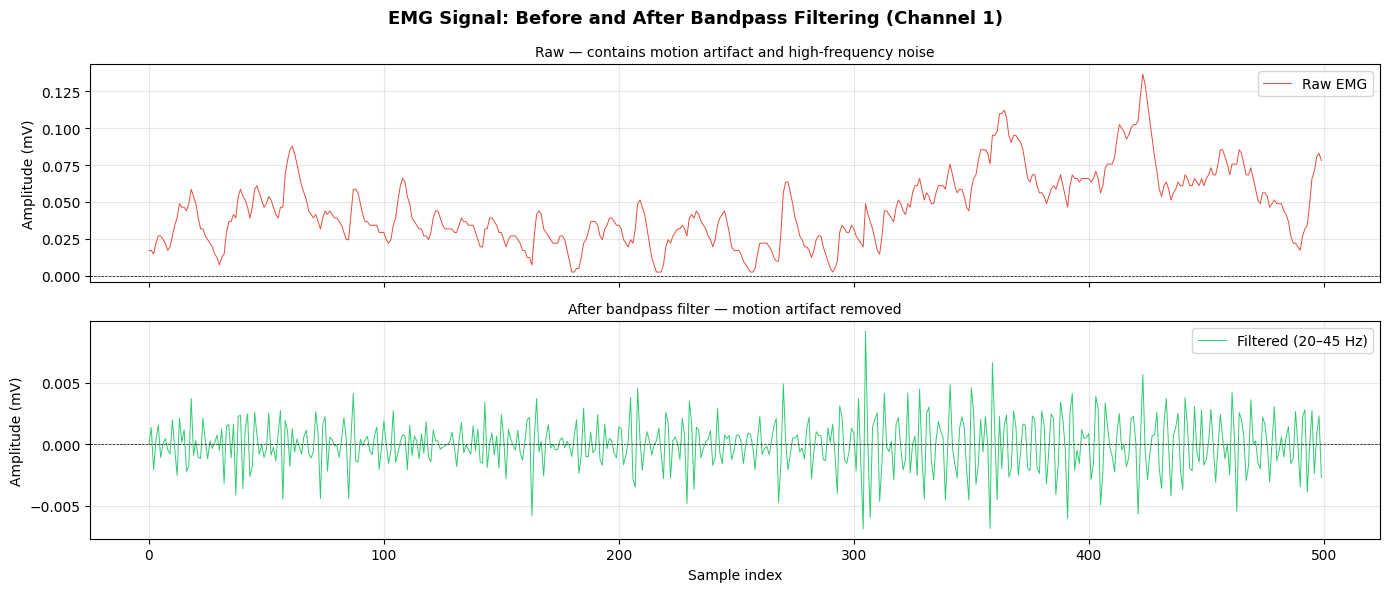

Figure saved: figures/raw_vs_filtered.png


In [16]:
processor = SignalProcessor()
filtered_emg_s1 = processor.filter(loader.emg)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle('EMG Signal: Before and After Bandpass Filtering (Channel 1)',
             fontsize=13, fontweight='bold')

axes[0].plot(loader.emg[:500, 0], color='#e74c3c',
             linewidth=0.7, label='Raw EMG')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].legend(loc='upper right')
axes[0].set_title('Raw — contains motion artifact and high-frequency noise',
                  fontsize=10)

axes[1].plot(filtered_emg_s1[:500, 0], color='#2ecc71',
             linewidth=0.7, label='Filtered (20–45 Hz)')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].set_xlabel('Sample index')
axes[1].legend(loc='upper right')
axes[1].set_title('After bandpass filter — motion artifact removed',
                  fontsize=10)

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig('../figures/raw_vs_filtered.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/raw_vs_filtered.png')

In [17]:
filepaths = [
    '../data/S1_E1_A1.mat',
    '../data/S2_E1_A1.mat',
    '../data/S3_E1_A1.mat',
]

emg, labels, reps = EMGDataLoader.load_multiple(filepaths)

print(f'\nCombined EMG shape:    {emg.shape}')
print(f'Labels shape:          {labels.shape}')
print(f'Unique gesture labels: {np.unique(labels)}')

Loaded ../data/S1_E1_A1.mat
  Samples: 101,014  Channels: 10
  Unique labels found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
After filtering to gestures [1, 2, 3, 4, 5, 6]:
  Remaining samples: 20,567
  Gesture 1: 3,815 samples
  Gesture 2: 2,618 samples
  Gesture 3: 4,142 samples
  Gesture 4: 2,982 samples
  Gesture 5: 3,952 samples
  Gesture 6: 3,058 samples
Loaded ../data/S2_E1_A1.mat
  Samples: 100,686  Channels: 10
  Unique labels found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
After filtering to gestures [1, 2, 3, 4, 5, 6]:
  Remaining samples: 21,257
  Gesture 1: 3,068 samples
  Gesture 2: 3,375 samples
  Gesture 3: 3,962 samples
  Gesture 4: 3,594 samples
  Gesture 5: 3,969 samples
  Gesture 6: 3,289 samples
Loaded ../data/S3_E1_A1.mat
  Samples: 100,720  Channels: 10
  Unique labels found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
After filtering to gestures [1, 2, 3, 4, 5, 6]:
  Remaining samples: 21,050
  Gesture 1: 3,031 samples
  Gesture 2: 4,111 samples
  Gesture 3: 

In [18]:
processor = SignalProcessor(fs=100, lowcut=20.0, highcut=45.0)
filtered_emg = processor.filter(emg)

windows, window_labels = processor.segment(filtered_emg, labels)

print(f'\nwindows shape:       {windows.shape}')
print(f'window_labels shape: {window_labels.shape}')
print(f'Unique labels in windows: {np.unique(window_labels)}')

Segmentation: 6,286 windows (200ms, 50% overlap)

windows shape:       (6286, 20, 10)
window_labels shape: (6286,)
Unique labels in windows: [1 2 3 4 5 6]


In [19]:
wlen = int(100 * 200 / 1000)   # 20 samples per window
step = int(wlen * 0.5)          # 10 samples stride

window_reps = []
for start in range(0, len(filtered_emg) - wlen, step):
    rep_slice = reps[start:start + wlen].astype(int)
    valid = rep_slice[rep_slice > 0]
    majority = int(np.bincount(valid).argmax()) if valid.size > 0 else 0
    window_reps.append(majority)

window_reps = np.array(window_reps[:len(windows)])

train_mask = window_reps <= 8
test_mask = window_reps >= 9

X_train_raw = windows[train_mask]
y_train = window_labels[train_mask]
X_test_raw = windows[test_mask]
y_test = window_labels[test_mask]

print(f'Training windows:  {X_train_raw.shape[0]:,}')
print(f'Test windows:      {X_test_raw.shape[0]:,}')
print(f'Train label set:   {np.unique(y_train)}')
print(f'Test label set:    {np.unique(y_test)}')

Training windows:  5,037
Test windows:      1,249
Train label set:   [1 2 3 4 5 6]
Test label set:    [1 2 3 4 5 6]


In [20]:
extractor = FeatureExtractor()
X_train_feats = extractor.extract_all(X_train_raw)
X_test_feats = extractor.extract_all(X_test_raw)

print(f'\nX_train shape: {X_train_feats.shape}  (windows × features)')
print(f'X_test shape:  {X_test_feats.shape}')

Feature matrix shape: (5037, 40) (windows * features)
Feature value range: [0.0000, 1.6661]
Feature matrix shape: (1249, 40) (windows * features)
Feature value range: [0.0000, 1.7575]

X_train shape: (5037, 40)  (windows × features)
X_test shape:  (1249, 40)


In [21]:
clf = GestureClassifier()
clf.cross_validate(X_train_feats, y_train)

5-Fold Cross-Validation   n_samples=5,037


KeyboardInterrupt: 

In [ ]:
# ── Cell 9: Final evaluation on held-out test set ────────────────────────────

clf.fit_and_evaluate(X_train_feats, X_test_feats, y_train, y_test)


Final Evaluation on Held-Out Test Set

--- SVM (RBF) ---
              precision    recall  f1-score   support

   Gesture 1      0.667     0.619     0.642       210
   Gesture 2      0.766     0.816     0.790       196
   Gesture 3      0.718     0.827     0.769       243
   Gesture 4      0.752     0.707     0.729       215
   Gesture 5      0.727     0.651     0.687       192
   Gesture 6      0.707     0.699     0.703       193

    accuracy                          0.723      1249
   macro avg      0.723     0.720     0.720      1249
weighted avg      0.722     0.723     0.721      1249


--- Random Forest ---
              precision    recall  f1-score   support

   Gesture 1      0.836     0.729     0.779       210
   Gesture 2      0.805     0.862     0.833       196
   Gesture 3      0.737     0.844     0.787       243
   Gesture 4      0.793     0.712     0.750       215
   Gesture 5      0.742     0.719     0.730       192
   Gesture 6      0.709     0.731     0.719       1

{'SVM (RBF)': {'cv_acc_mean': np.float64(0.8552720244006242),
  'cv_acc_std': np.float64(0.004468190385881422),
  'cv_f1_mean': np.float64(0.8553501663917699),
  'cv_f1_std': np.float64(0.004385068662462808),
  'confusion_matrix': array([[130,  29,  16,  23,   6,   6],
         [ 12, 160,  13,  10,   1,   0],
         [  8,   5, 201,   5,  14,  10],
         [ 17,  11,  13, 152,  13,   9],
         [ 13,   0,  20,   3, 125,  31],
         [ 15,   4,  17,   9,  13, 135]]),
  'y_test': array([1, 1, 1, ..., 6, 6, 6], shape=(1249,)),
  'y_pred': array([1, 1, 3, ..., 6, 3, 3], shape=(1249,)),
  'model': Pipeline(steps=[('scaler', StandardScaler()),
                  ('clf', SVC(C=10, random_state=42))])},
 'Random Forest': {'cv_acc_mean': np.float64(0.8630148484418594),
  'cv_acc_std': np.float64(0.0071655055806968395),
  'cv_f1_mean': np.float64(0.862553671966887),
  'cv_f1_std': np.float64(0.007445368953096199),
  'confusion_matrix': array([[153,  25,   8,  15,   5,   4],
         [  1, 1

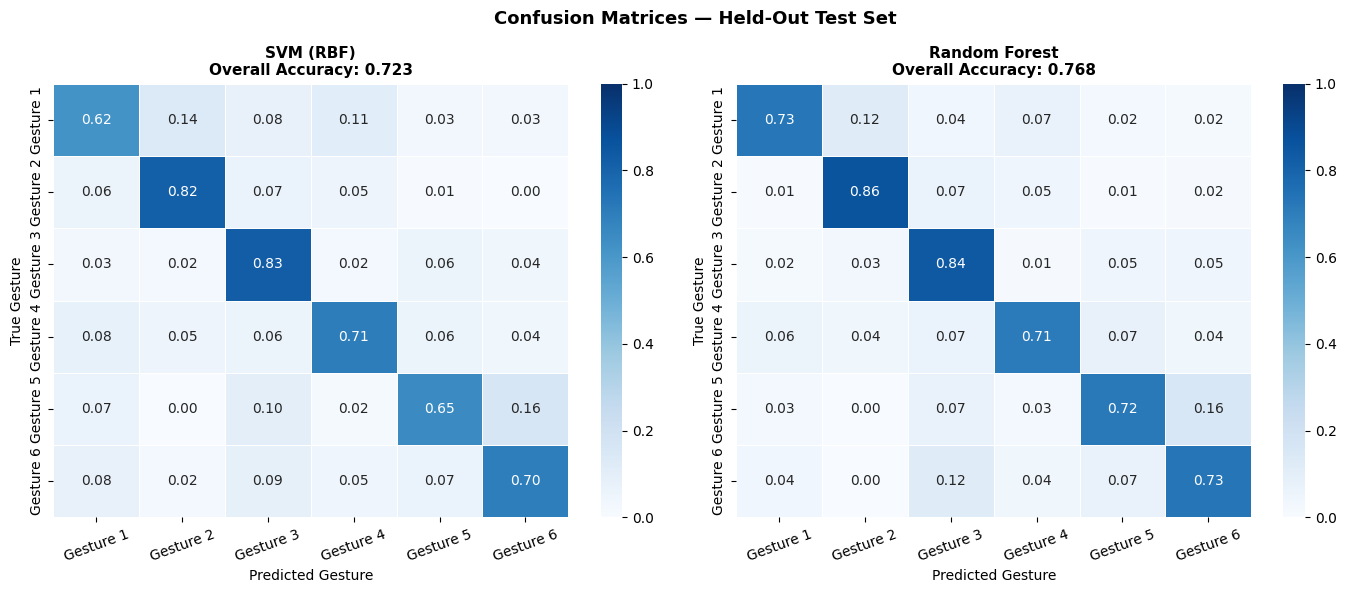

Figure saved: figures/confusion_matrices.png


In [ ]:
gesture_names = ['Gesture 1', 'Gesture 2', 'Gesture 3',
                 'Gesture 4', 'Gesture 5', 'Gesture 6']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrices — Held-Out Test Set',
             fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, clf.results.items()):
    cm = res['confusion_matrix']
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax,
                cmap='Blues', xticklabels=gesture_names,
                yticklabels=gesture_names,
                vmin=0, vmax=1, linewidths=0.5)

    overall_acc = accuracy_score(res['y_test'], res['y_pred'])
    ax.set_title(f'{name}\nOverall Accuracy: {overall_acc:.3f}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted Gesture', fontsize=10)
    ax.set_ylabel('True Gesture', fontsize=10)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/confusion_matrices.png')

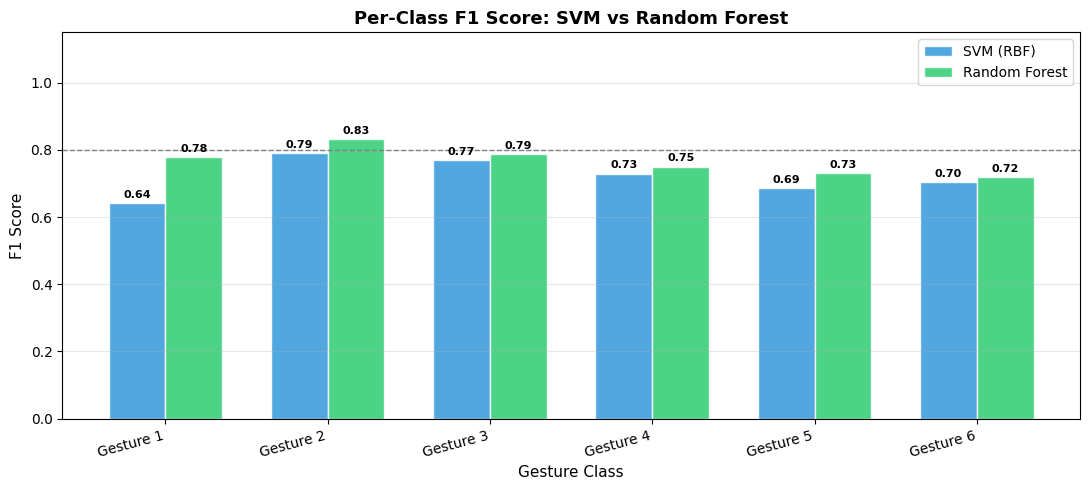

Figure saved: figures/f1_comparison.png


In [ ]:
x = np.arange(len(gesture_names))
width = 0.35
colors = ['#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(11, 5))

for i, (name, res) in enumerate(clf.results.items()):
    f1_per_class = f1_score(res['y_test'], res['y_pred'],
                            average=None, labels=[1, 2, 3, 4, 5, 6])
    bars = ax.bar(x + i * width, f1_per_class, width,
                  label=name, color=colors[i], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, f1_per_class):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

ax.set_xlabel('Gesture Class', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('Per-Class F1 Score: SVM vs Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(gesture_names, rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.8, color='gray', linewidth=1, linestyle='--')

plt.tight_layout()
plt.savefig('../figures/f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/f1_comparison.png')

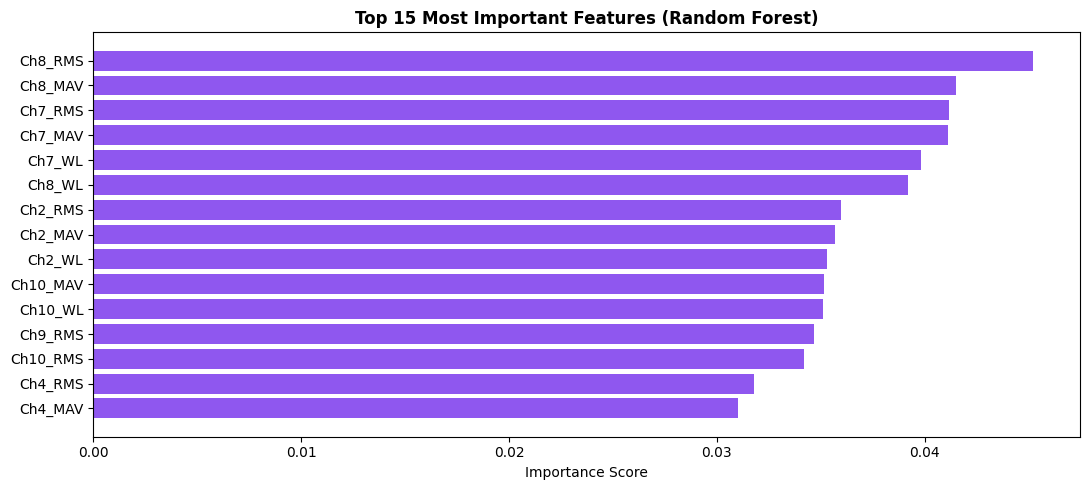

Figure saved: figures/feature_importance.png


In [ ]:
importances = clf.get_feature_importance()
feature_names = [f'Ch{ch+1}_{feat}'
                 for ch in range(10)
                 for feat in ['RMS', 'MAV', 'ZCR', 'WL']]

top_idx = np.argsort(importances)[-15:][::-1]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh([feature_names[i] for i in top_idx],
        importances[top_idx],
        color='#7c3aed', alpha=0.85)
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Most Important Features (Random Forest)',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/feature_importance.png')

In [ ]:
print('=' * 50)
print('RESULTS SUMMARY — copy into README')
print('=' * 50)
for name, res in clf.results.items():
    print(f'\n{name}')
    print(f"  CV Accuracy: {res['cv_acc_mean']:.3f} ± {res['cv_acc_std']:.3f}")
    print(f"  CV F1:       {res['cv_f1_mean']:.3f} ± {res['cv_f1_std']:.3f}")
    print(f"  Test Acc:    {accuracy_score(res['y_test'], res['y_pred']):.3f}")
print('\nFigures saved in figures/ folder.')

RESULTS SUMMARY — copy into README

SVM (RBF)
  CV Accuracy: 0.855 ± 0.004
  CV F1:       0.855 ± 0.004
  Test Acc:    0.723

Random Forest
  CV Accuracy: 0.863 ± 0.007
  CV F1:       0.863 ± 0.007
  Test Acc:    0.768

Figures saved in figures/ folder.
